<a href="https://colab.research.google.com/github/Fredy1239/TalentoTech2/blob/Prueba/CuartaHojaFredyGHG_Emissions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

$$ Llamando \space las \space librerías \space que \space voy \space a \space utilizar \space durante \space el \space análisis $$

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


$$ Leyendo \space el \space archivo$$

---


In [ ]:
xls = pd.read_excel("/content/drive/MyDrive/GHGHighlights.XLS", sheet_name=['GHG Energy', 'SECTOR', 'CO2-GDP', 'SECTPOP'], skiprows=3, index_col=None)
xls

{'GHG Energy':     million tonnes of CO2 eq  \
 0                        NaN   
 1                      World   
 2                        NaN   
 3           Annex I Parties    
 4        Annex II Parties      
 ..                       ...   
 190                   Europe   
 191                  Oceania   
 192                      NaN   
 193                      NaN   
 194                      NaN   
 
                                                   1971         1972  \
 0                                                  NaN          NaN   
 1                                          16732.86343  17450.87455   
 2                                                  NaN          NaN   
 3                                                   ..           ..   
 4                                                   ..           ..   
 ..                                                 ...          ...   
 190                                                 ..           ..   
 191        

In [ ]:
df_GHF_Energy = xls['GHG Energy']
df_SECTOR = xls['SECTOR']
df_CO2_GDP = xls['CO2-GDP']
df_SECTPOP = xls['SECTPOP']

In [ ]:
df_SECTPOP.head(20)

,kgCO2 / capita,Total CO2 emissions \nfrom fuel combustion,Electricity and heat production,Other energy \nindustry own use,Manuf. industries \nand construction,Transport,of which: road,Residential,Commercial and public services,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,World,4293,1881,209,788,999,758,244,98,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Annex I Parties,8648,3162,510,1123,2575,2196,748,367,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Annex II Parties,9158,3067,627,1100,3035,2622,728,445,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,North America,13774,4517,1021,1402,5002,4160,956,721,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Europe,5315,1434,338,734,1752,1644,658,244,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Asia Oceania,8694,4088,476,1386,1860,1636,377,341,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Annex I EIT,8172,3913,233,1273,1513,1152,903,138,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Non-Annex I Parties,3242,1622,148,720,510,467,142,44,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Lista de índices a eliminar
filas_a_eliminar = [0, 2] + list(range(3, 13)) + list(range(15, 18)) + list(range(181, 197))

# Eliminar todas las filas de una vez
df_SECTPOP_V1 = df_SECTPOP.drop(index=filas_a_eliminar)

df_SECTPOP_V1.head(20)

,kgCO2 / capita,Total CO2 emissions \nfrom fuel combustion,Electricity and heat production,Other energy \nindustry own use,Manuf. industries \nand construction,Transport,of which: road,Residential,Commercial and public services,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18
1,World,4293,1881,209,788,999,758,244,98,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13,OECD Total,7828,2736,527,963,2500,2199,611,352,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14,Non-OECD Total,3379,1701,143,751,512,455,167,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18,Canada,13440,1869,3280,1714,4211,3497,978,887,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19,Chile,4367,1480,94,807,1573,1441,235,114,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20,Colombia,1452,255,76,236,715,709,112,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21,Costa Rica,1454,1,0,238,1095,1089,51,31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22,Mexico,2953,982,355,350,1010,982,146,36,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23,United States,13813,4826,758,1365,5095,4237,953,701,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24,OECD Americas,9847,3210,749,1034,3583,3028,668,480,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_SECTPOP_V1.tail(20)

,kgCO2 / capita,Total CO2 emissions \nfrom fuel combustion,Electricity and heat production,Other energy \nindustry own use,Manuf. industries \nand construction,Transport,of which: road,Residential,Commercial and public services,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18
161,Paraguay,1087,0,0,40,904,897,29,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
162,Peru,1669,372,80,297,787,762,86,38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
163,Suriname,4584,1889,49,175,1525,876,99,56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
164,Trinidad and Tobago,8955,3493,2328,1207,1667,1570,248,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
165,Uruguay,2097,232,113,282,1206,1192,117,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
166,Venezuela,2249,458,644,510,519,508,93,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
167,Other Non-OECD Americas,2000,1013,2,138,682,572,89,57,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
168,Non-OECD Americas,2032,399,143,371,875,814,134,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
169,Bahrain,23378,16903,2198,1522,2578,2529,155,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
170,Islamic Rep. of Iran,7864,2228,593,1502,1606,1582,1500,226,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Borrar columnas desde la 9
df_SECTPOP_V1 = df_SECTPOP_V1.drop(df_SECTPOP_V1.columns[9:], axis=1)
df_SECTPOP_V1

,kgCO2 / capita,Total CO2 emissions \nfrom fuel combustion,Electricity and heat production,Other energy \nindustry own use,Manuf. industries \nand construction,Transport,of which: road,Residential,Commercial and public services
1,World,4293,1881,209,788,999,758,244,98
13,OECD Total,7828,2736,527,963,2500,2199,611,352
14,Non-OECD Total,3379,1701,143,751,512,455,167,45
18,Canada,13440,1869,3280,1714,4211,3497,978,887
19,Chile,4367,1480,94,807,1573,1441,235,114
...,...,...,...,...,...,...,...,...,...
176,Qatar,33643,9601,11766,7823,4298,4298,155,0
177,Saudi Arabia,14636,7142,847,2723,3784,3717,141,0
178,Syrian Arab Republic,1244,753,27,108,225,211,82,16
179,United Arab Emirates,18392,6897,249,7412,3770,3643,65,0


In [ ]:
df_SECTPOP_V1 = df_SECTPOP_V1
df_SECTPOP_V1.head(10) # Verificamos los cambios


,kgCO2 / capita,Total CO2 emissions \nfrom fuel combustion,Electricity and heat production,Other energy \nindustry own use,Manuf. industries \nand construction,Transport,of which: road,Residential,Commercial and public services
1,World,4293,1881,209,788,999,758,244,98
13,OECD Total,7828,2736,527,963,2500,2199,611,352
14,Non-OECD Total,3379,1701,143,751,512,455,167,45
18,Canada,13440,1869,3280,1714,4211,3497,978,887
19,Chile,4367,1480,94,807,1573,1441,235,114
20,Colombia,1452,255,76,236,715,709,112,23
21,Costa Rica,1454,1,0,238,1095,1089,51,31
22,Mexico,2953,982,355,350,1010,982,146,36
23,United States,13813,4826,758,1365,5095,4237,953,701
24,OECD Americas,9847,3210,749,1034,3583,3028,668,480


In [ ]:
df_SECTPOP_V2 = df_SECTPOP_V1.set_index(df_SECTPOP_V1.columns[0]) # Establecemos la primera columna como indice
df_SECTPOP_V2.head(30)

,Total CO2 emissions \nfrom fuel combustion,Electricity and heat production,Other energy \nindustry own use,Manuf. industries \nand construction,Transport,of which: road,Residential,Commercial and public services
kgCO2 / capita,,,,,,,,
World,4293,1881,209,788,999,758,244,98
OECD Total,7828,2736,527,963,2500,2199,611,352
Non-OECD Total,3379,1701,143,751,512,455,167,45
Canada,13440,1869,3280,1714,4211,3497,978,887
Chile,4367,1480,94,807,1573,1441,235,114
Colombia,1452,255,76,236,715,709,112,23
Costa Rica,1454,1,0,238,1095,1089,51,31
Mexico,2953,982,355,350,1010,982,146,36
United States,13813,4826,758,1365,5095,4237,953,701


In [ ]:
# Mostramos las columnas del  dataframe
# Son los países
df_SECTPOP_V2.columns

Index(['Total CO2 emissions \nfrom fuel combustion',
       'Electricity and heat production', 'Other energy \nindustry own use',
       'Manuf. industries \nand construction', 'Transport', 'of which: road',
       'Residential', 'Commercial and public services'],
      dtype='object')

In [ ]:
df_SECTPOP_V2.isnull() # verificando valores nulos

,Total CO2 emissions \nfrom fuel combustion,Electricity and heat production,Other energy \nindustry own use,Manuf. industries \nand construction,Transport,of which: road,Residential,Commercial and public services
kgCO2 / capita,,,,,,,,
World,False,False,False,False,False,False,False,False
OECD Total,False,False,False,False,False,False,False,False
Non-OECD Total,False,False,False,False,False,False,False,False
Canada,False,False,False,False,False,False,False,False
Chile,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
Qatar,False,False,False,False,False,False,False,False
Saudi Arabia,False,False,False,False,False,False,False,False
Syrian Arab Republic,False,False,False,False,False,False,False,False


In [ ]:
df_SECTPOP_V2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 166 entries, World to Yemen
Data columns (total 8 columns):
 #   Column                                     Non-Null Count  Dtype 
---  ------                                     --------------  ----- 
 0   Total CO2 emissions 
from fuel combustion  166 non-null    object
 1   Electricity and heat production            166 non-null    object
 2   Other energy 
industry own use             166 non-null    object
 3   Manuf. industries 
and construction        166 non-null    object
 4   Transport                                  166 non-null    object
 5   of which: road                             166 non-null    object
 6   Residential                                166 non-null    object
 7   Commercial and public services             166 non-null    object
dtypes: object(8)
memory usage: 11.7+ KB


In [ ]:
# Reemplazamos los ".." (Campos sin datos) por None
# Reemplazamos los "-"(Campos sin datos) por None
df_SECTPOP_V2.replace("x",None, inplace=True)
df_SECTPOP_V2.replace("-",None, inplace=True)
df_SECTPOP_V2

,Total CO2 emissions \nfrom fuel combustion,Electricity and heat production,Other energy \nindustry own use,Manuf. industries \nand construction,Transport,of which: road,Residential,Commercial and public services
kgCO2 / capita,,,,,,,,
World,4293,1881,209,788,999,758,244,98
OECD Total,7828,2736,527,963,2500,2199,611,352
Non-OECD Total,3379,1701,143,751,512,455,167,45
Canada,13440,1869,3280,1714,4211,3497,978,887
Chile,4367,1480,94,807,1573,1441,235,114
...,...,...,...,...,...,...,...,...
Qatar,33643,9601,11766,7823,4298,4298,155,0
Saudi Arabia,14636,7142,847,2723,3784,3717,141,0
Syrian Arab Republic,1244,753,27,108,225,211,82,16


In [ ]:
b = list(df_SECTPOP_V2.columns)
print(b)

['Total CO2 emissions \nfrom fuel combustion', 'Electricity and heat production', 'Other energy \nindustry own use', 'Manuf. industries \nand construction', 'Transport', 'of which: road', 'Residential', 'Commercial and public services']


In [ ]:
# Cambia el tipo de datos de las columnas a float
df_SECTPOP_V2[b] = df_SECTPOP_V2[b].astype(float)


In [ ]:
df_SECTPOP_V2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 166 entries, World to Yemen
Data columns (total 8 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Total CO2 emissions 
from fuel combustion  164 non-null    float64
 1   Electricity and heat production            164 non-null    float64
 2   Other energy 
industry own use             164 non-null    float64
 3   Manuf. industries 
and construction        164 non-null    float64
 4   Transport                                  164 non-null    float64
 5   of which: road                             164 non-null    float64
 6   Residential                                164 non-null    float64
 7   Commercial and public services             164 non-null    float64
dtypes: float64(8)
memory usage: 11.7+ KB


In [ ]:
duplicate_columns = df_SECTPOP_V2.columns[df_SECTPOP_V2.columns.duplicated()]
duplicate_columns

Index([], dtype='object')

In [ ]:
!pip install miceforest


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 1.8 MB/s eta 0:00:00


In [ ]:
import miceforest as mf

In [ ]:
# Borramos paises sin datos
df_SECTPOP_V2 = df_SECTPOP_V2.dropna()

In [ ]:
# Contar los valores nulos presentes en el dataframe
print(df_SECTPOP_V2.isnull().sum())

Total CO2 emissions \nfrom fuel combustion    0
Electricity and heat production               0
Other energy \nindustry own use               0
Manuf. industries \nand construction          0
Transport                                     0
of which: road                                0
Residential                                   0
Commercial and public services                0
dtype: int64


In [ ]:
df_SECTPOP_V2


,Total CO2 emissions \nfrom fuel combustion,Electricity and heat production,Other energy \nindustry own use,Manuf. industries \nand construction,Transport,of which: road,Residential,Commercial and public services
kgCO2 / capita,,,,,,,,
World,4293.0,1881.0,209.0,788.0,999.0,758.0,244.0,98.0
OECD Total,7828.0,2736.0,527.0,963.0,2500.0,2199.0,611.0,352.0
Non-OECD Total,3379.0,1701.0,143.0,751.0,512.0,455.0,167.0,45.0
Canada,13440.0,1869.0,3280.0,1714.0,4211.0,3497.0,978.0,887.0
Chile,4367.0,1480.0,94.0,807.0,1573.0,1441.0,235.0,114.0
...,...,...,...,...,...,...,...,...
Qatar,33643.0,9601.0,11766.0,7823.0,4298.0,4298.0,155.0,0.0
Saudi Arabia,14636.0,7142.0,847.0,2723.0,3784.0,3717.0,141.0,0.0
Syrian Arab Republic,1244.0,753.0,27.0,108.0,225.0,211.0,82.0,16.0


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

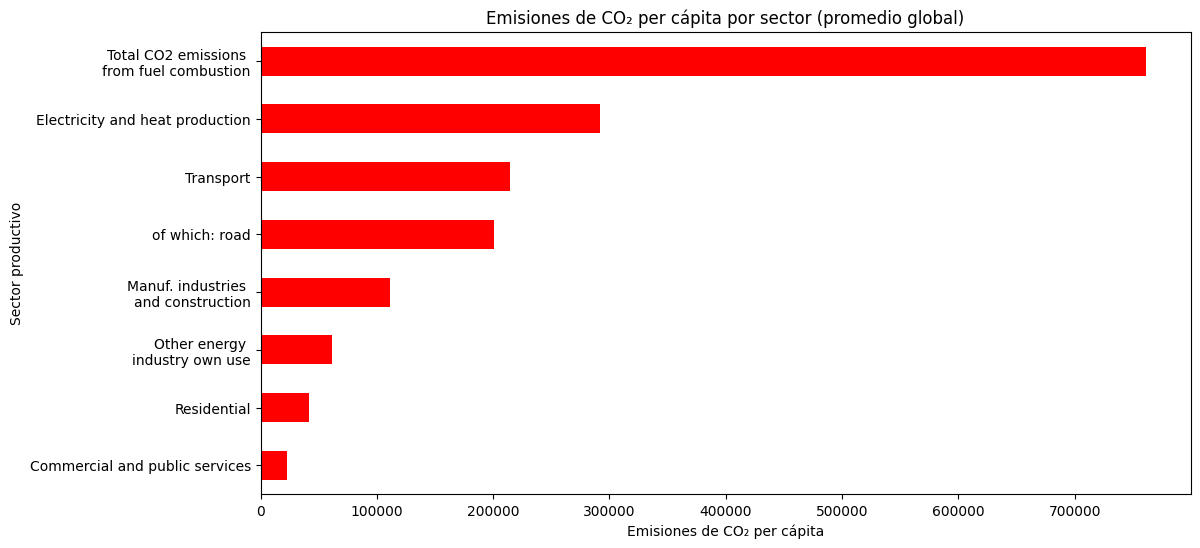

In [ ]:
# Emisiones totales de CO2 per capita por sector productivo
df_SECTPOP_V2.sum().sort_values().plot(kind="barh", figsize=(12,6), color="red")
plt.title("Emisiones de CO₂ per cápita por sector (promedio global)")
plt.xlabel("Emisiones de CO₂ per cápita")
plt.ylabel("Sector productivo")
plt.show()

In [ ]:
# Descargar el dataframe como excel
df_SECTPOP_V2.to_excel('df_SECTPOP_V2.xlsx')

In [ ]:
df3 = df_SECTPOP_V2.transpose()
df3

kgCO2 / capita,World,OECD Total,Non-OECD Total,Canada,Chile,Colombia,Costa Rica,Mexico,United States,OECD Americas,...,Iraq,Jordan,Kuwait,Lebanon,Oman,Qatar,Saudi Arabia,Syrian Arab Republic,United Arab Emirates,Yemen
Total CO2 emissions \nfrom fuel combustion,4293.0,7828.0,3379.0,13440.0,4367.0,1452.0,1454.0,2953.0,13813.0,9847.0,...,3825.0,1892.0,22051.0,1718.0,16372.0,33643.0,14636.0,1244.0,18392.0,244.0
Electricity and heat production,1881.0,2736.0,1701.0,1869.0,1480.0,255.0,1.0,982.0,4826.0,3210.0,...,2037.0,753.0,10691.0,357.0,3463.0,9601.0,7142.0,753.0,6897.0,48.0
Other energy \nindustry own use,209.0,527.0,143.0,3280.0,94.0,76.0,0.0,355.0,758.0,749.0,...,327.0,14.0,3570.0,0.0,2575.0,11766.0,847.0,27.0,249.0,9.0
Manuf. industries \nand construction,788.0,963.0,751.0,1714.0,807.0,236.0,238.0,350.0,1365.0,1034.0,...,329.0,171.0,3502.0,121.0,2897.0,7823.0,2723.0,108.0,7412.0,32.0
Transport,999.0,2500.0,512.0,4211.0,1573.0,715.0,1095.0,1010.0,5095.0,3583.0,...,920.0,695.0,4038.0,1164.0,2907.0,4298.0,3784.0,225.0,3770.0,80.0
of which: road,758.0,2199.0,455.0,3497.0,1441.0,709.0,1089.0,982.0,4237.0,3028.0,...,920.0,692.0,4038.0,1164.0,2886.0,4298.0,3717.0,211.0,3643.0,80.0
Residential,244.0,611.0,167.0,978.0,235.0,112.0,51.0,146.0,953.0,668.0,...,212.0,156.0,248.0,77.0,161.0,155.0,141.0,82.0,65.0,62.0
Commercial and public services,98.0,352.0,45.0,887.0,114.0,23.0,31.0,36.0,701.0,480.0,...,0.0,42.0,0.0,0.0,3796.0,0.0,0.0,16.0,0.0,7.0


In [ ]:
# Cambiar nombre de columnas
df4 = df3.rename(columns ={"Manuf. industries \nand construction":"Manuf.industries and construction","Other energy \nindustry own use":"Other Energy Industry own use"})
df4

kgCO2 / capita,World,OECD Total,Non-OECD Total,Canada,Chile,Colombia,Costa Rica,Mexico,United States,OECD Americas,...,Iraq,Jordan,Kuwait,Lebanon,Oman,Qatar,Saudi Arabia,Syrian Arab Republic,United Arab Emirates,Yemen
Total CO2 emissions \nfrom fuel combustion,4293.0,7828.0,3379.0,13440.0,4367.0,1452.0,1454.0,2953.0,13813.0,9847.0,...,3825.0,1892.0,22051.0,1718.0,16372.0,33643.0,14636.0,1244.0,18392.0,244.0
Electricity and heat production,1881.0,2736.0,1701.0,1869.0,1480.0,255.0,1.0,982.0,4826.0,3210.0,...,2037.0,753.0,10691.0,357.0,3463.0,9601.0,7142.0,753.0,6897.0,48.0
Other energy \nindustry own use,209.0,527.0,143.0,3280.0,94.0,76.0,0.0,355.0,758.0,749.0,...,327.0,14.0,3570.0,0.0,2575.0,11766.0,847.0,27.0,249.0,9.0
Manuf. industries \nand construction,788.0,963.0,751.0,1714.0,807.0,236.0,238.0,350.0,1365.0,1034.0,...,329.0,171.0,3502.0,121.0,2897.0,7823.0,2723.0,108.0,7412.0,32.0
Transport,999.0,2500.0,512.0,4211.0,1573.0,715.0,1095.0,1010.0,5095.0,3583.0,...,920.0,695.0,4038.0,1164.0,2907.0,4298.0,3784.0,225.0,3770.0,80.0
of which: road,758.0,2199.0,455.0,3497.0,1441.0,709.0,1089.0,982.0,4237.0,3028.0,...,920.0,692.0,4038.0,1164.0,2886.0,4298.0,3717.0,211.0,3643.0,80.0
Residential,244.0,611.0,167.0,978.0,235.0,112.0,51.0,146.0,953.0,668.0,...,212.0,156.0,248.0,77.0,161.0,155.0,141.0,82.0,65.0,62.0
Commercial and public services,98.0,352.0,45.0,887.0,114.0,23.0,31.0,36.0,701.0,480.0,...,0.0,42.0,0.0,0.0,3796.0,0.0,0.0,16.0,0.0,7.0


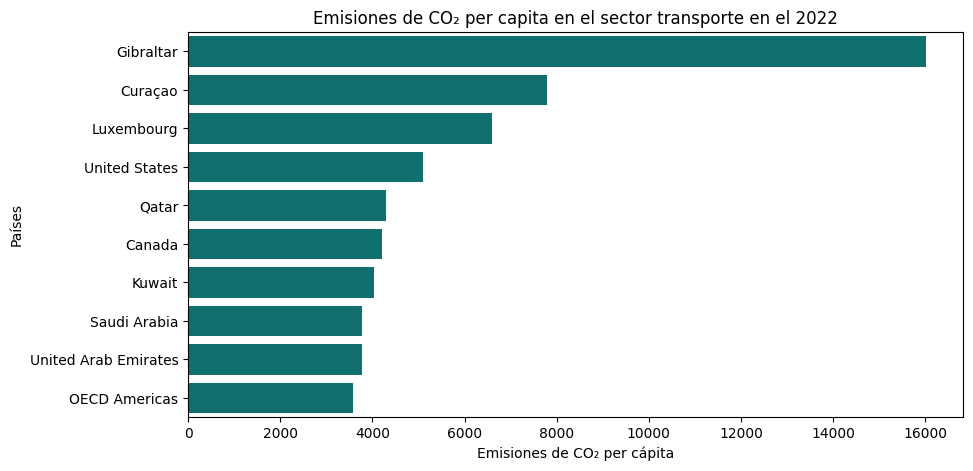

In [ ]:
# Creamos un Dataframe en base a una sola columna del original
emisiones_transporte = df3.loc["Transport"]
# Organizamos los valores en base a los 10 que mas emiten en ese sector
paises_top= emisiones_transporte.sort_values(ascending=False).head(10)
# Graficamos
plt.figure(figsize=(10,5)) # Tamaño de la figura
sns.barplot(x=paises_top.values,y=paises_top.index,color="teal") # Tipo de grafica
plt.title("Emisiones de CO₂ per capita en el sector transporte en el 2022")
plt.xlabel("Emisiones de CO₂ per cápita")
plt.ylabel("Países")
plt.show()

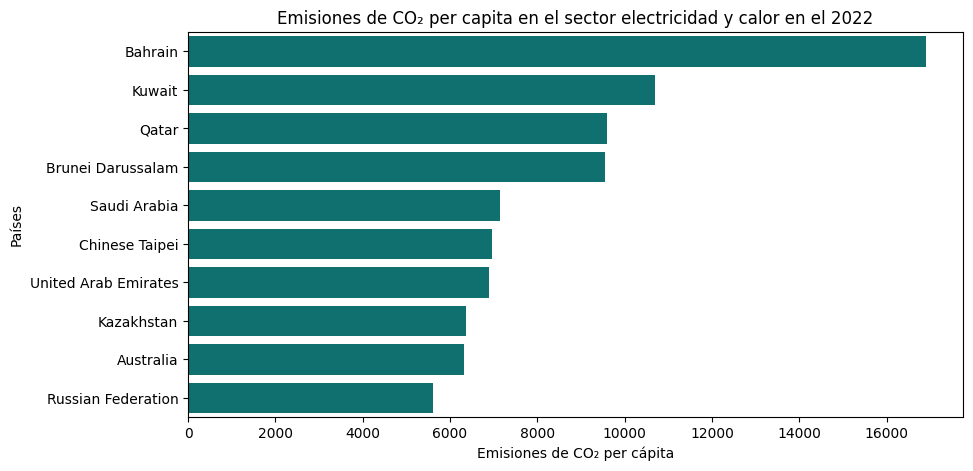

In [ ]:
df4 = df3.loc["Electricity and heat production"]
emisiones_electricidad = df4.sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=emisiones_electricidad.values, y=emisiones_electricidad.index, color="teal")
plt.title("Emisiones de CO₂ per capita en el sector electricidad y calor en el 2022")
plt.xlabel("Emisiones de CO₂ per cápita")
plt.ylabel("Países")
plt.show()

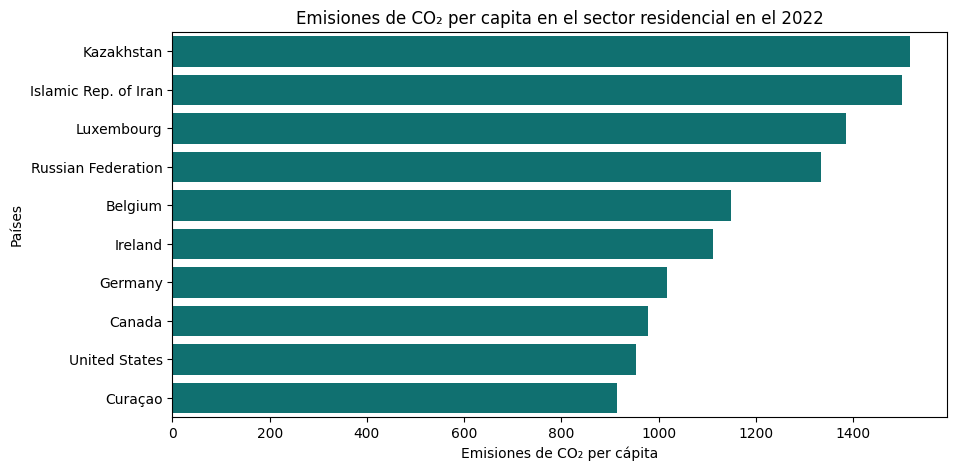

In [ ]:
df5 =df3.loc["Residential"]
emisiones_residencial = df5.sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=emisiones_residencial.values, y=emisiones_residencial.index, color="teal")
plt.title("Emisiones de CO₂ per capita en el sector residencial en el 2022")
plt.xlabel("Emisiones de CO₂ per cápita")
plt.ylabel("Países")
plt.show()

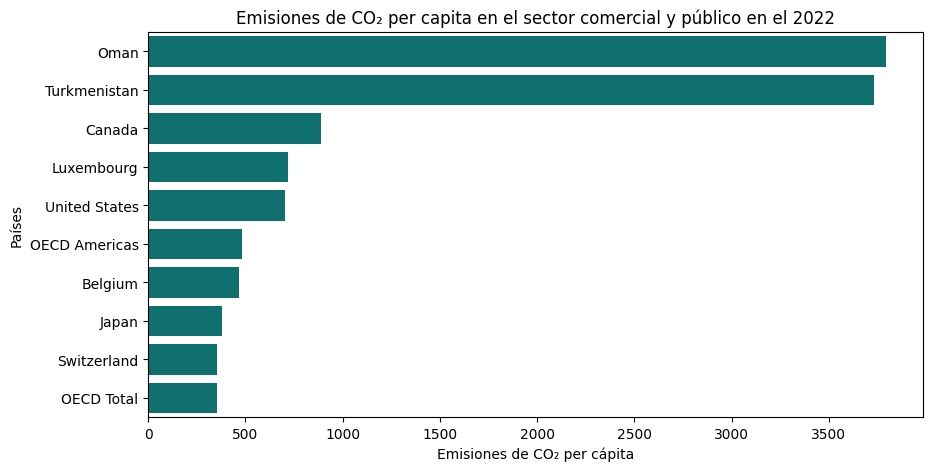

In [ ]:
df7 = df3.loc["Commercial and public services"]
emisiones_comerciales = df7.sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=emisiones_comerciales.values, y=emisiones_comerciales.index, color="teal")
plt.title("Emisiones de CO₂ per capita en el sector comercial y público en el 2022")
plt.xlabel("Emisiones de CO₂ per cápita")
plt.ylabel("Países")
plt.show()


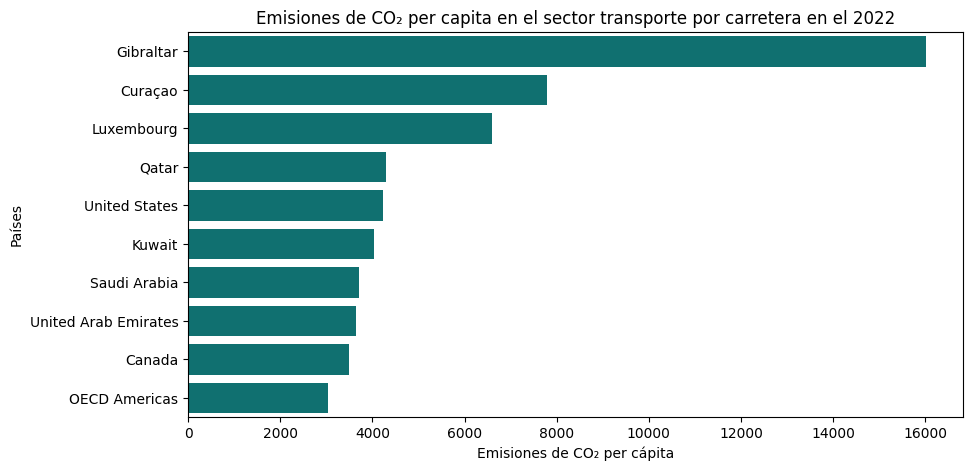

In [ ]:
# Transporte por carretera
df8= df3.loc["of which: road"]
Emisiones_carretera = df8.sort_values(ascending = False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=Emisiones_carretera.values, y=Emisiones_carretera.index, color="teal")
plt.title("Emisiones de CO₂ per capita en el sector transporte por carretera en el 2022")
plt.xlabel("Emisiones de CO₂ per cápita")
plt.ylabel("Países")
plt.show()


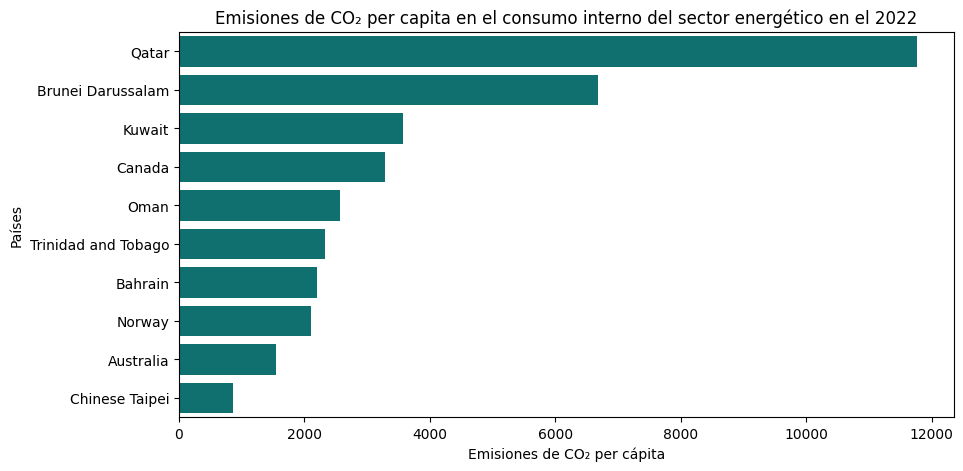

In [ ]:
df9 = df3.loc["Other energy \nindustry own use"]
Emisiones_consumointerno = df9.sort_values(ascending = False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=Emisiones_consumointerno.values, y=Emisiones_consumointerno.index, color="teal")
plt.title("Emisiones de CO₂ per capita en el consumo interno del sector energético en el 2022")
plt.xlabel("Emisiones de CO₂ per cápita")
plt.ylabel("Países")
plt.show()

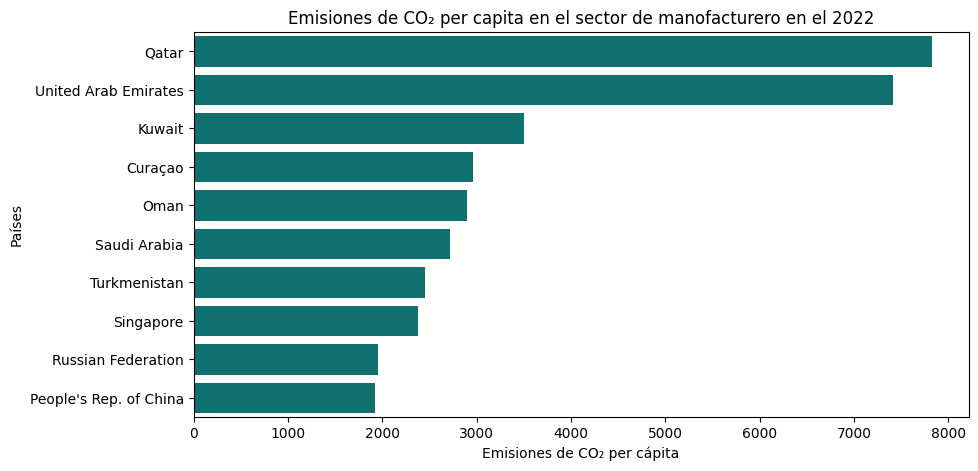

In [ ]:
df10 = df3.loc['Manuf. industries \nand construction']
emisiones_sectormanufacturero = df10.sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=emisiones_sectormanufacturero.values, y=emisiones_sectormanufacturero.index, color="teal")
plt.title("Emisiones de CO₂ per capita en el sector de manofacturero en el 2022")
plt.xlabel("Emisiones de CO₂ per cápita")
plt.ylabel("Países")
plt.show()

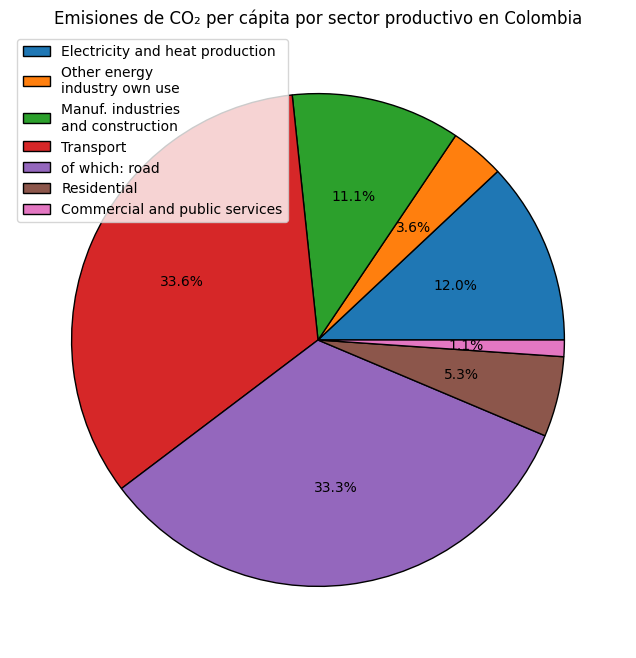

In [ ]:
df_colombia = df3["Colombia"]
df_colombia.drop(df_colombia.index[0], inplace=True)
plt.figure(figsize=(10,8))
plt.pie(df_colombia, autopct='%1.1f%%',wedgeprops={"edgecolor": "black"})
plt.title("Emisiones de CO₂ per cápita por sector productivo en Colombia")
plt.legend(labels = df_colombia.index, loc="best")
plt.show()


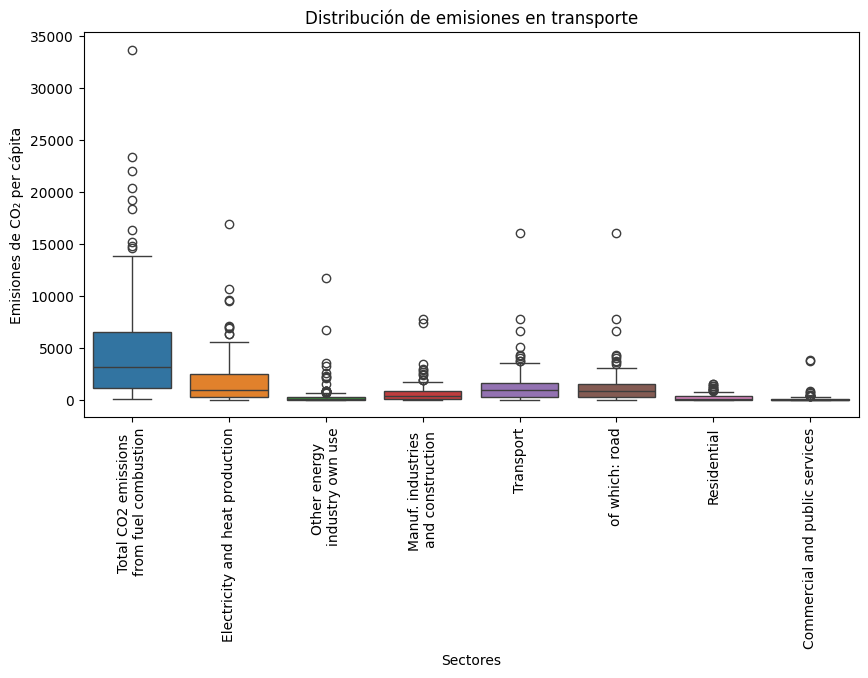

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df_SECTPOP_V2)
plt.title("Distribución de emisiones en transporte")
plt.xlabel("Sectores")
plt.ylabel("Emisiones de CO₂ per cápita")
plt.xticks(rotation=90)
plt.show()

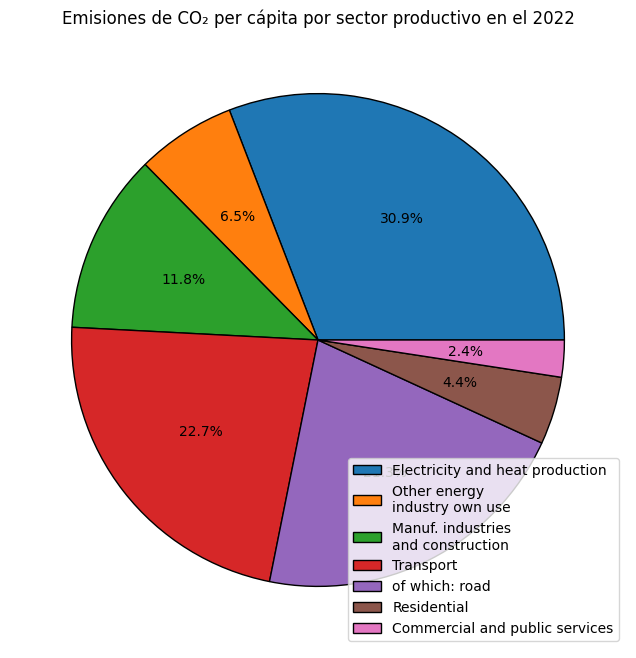

In [ ]:
df_pieplot= df3.drop(df3.index[0])
df_pieplot= df_pieplot.sum(axis=1)
plt.figure(figsize=(10,8))
plt.pie(df_pieplot, autopct='%1.1f%%',wedgeprops={"edgecolor": "black"})
plt.title("Emisiones de CO₂ per cápita por sector productivo en el 2022")
plt.legend(labels = df_pieplot.index, loc="best")
plt.show()